In [ ]:
!pip install pykan scikit-learn matplotlib seaborn pandas

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from kan import KAN

In [ ]:
data = fetch_california_housing()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train.reshape(-1,1), dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

In [ ]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
def train_mlp(model, X, y, epochs=50, lr=0.01):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    for _ in range(epochs):
        optimizer.zero_grad()
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()

In [ ]:
def compute_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

    return {"RMSE": rmse, "MAE": mae, "R2": r2, "MAPE": mape}

In [ ]:
def compute_ci(metric_list):
    ci_results = {}

    for key in metric_list[0].keys():
        values = np.array([m[key] for m in metric_list])

        mean = np.mean(values)
        std = np.std(values)
        n = len(values)

        margin = 1.96 * (std / np.sqrt(n))

        ci_results[key] = (mean, mean - margin, mean + margin)

    return ci_results

In [ ]:
widths = [5, 10, 20]
grids = [3, 5, 10]
runs = 5

results = []

for width in widths:
    for grid in grids:

        kan_all = []
        mlp_all = []

        for r in range(runs):

            # ----- KAN -----
            model_kan = KAN(width=[X.shape[1], width, 1], grid=grid, k=3)

            # Manual KAN training loop
            optimizer_kan = torch.optim.Adam(model_kan.parameters(), lr=0.01)
            loss_fn_kan = nn.MSELoss()

            for step in range(50): # Using 50 steps as in previous attempts
                optimizer_kan.zero_grad()
                pred_kan_train = model_kan(X_train_t)
                loss_kan = loss_fn_kan(pred_kan_train, y_train_t)
                loss_kan.backward()
                optimizer_kan.step()

            y_pred_kan = model_kan(X_test_t).detach().numpy().flatten()
            kan_all.append(compute_metrics(y_test, y_pred_kan))

            # ----- MLP -----
            mlp = MLP(X.shape[1], width)
            train_mlp(mlp, X_train_t, y_train_t)

            y_pred_mlp = mlp(X_test_t).detach().numpy().flatten()
            mlp_all.append(compute_metrics(y_test, y_pred_mlp))

        kan_ci = compute_ci(kan_all)
        mlp_ci = compute_ci(mlp_all)

        results.append({
            "width": width,
            "grid": grid,

            "KAN_RMSE": kan_ci["RMSE"][0],
            "KAN_RMSE_low": kan_ci["RMSE"][1],
            "KAN_RMSE_high": kan_ci["RMSE"][2],

            "KAN_MAE": kan_ci["MAE"][0],
            "KAN_R2": kan_ci["R2"][0],
            "KAN_MAPE": kan_ci["MAPE"][0],

            "MLP_RMSE": mlp_ci["RMSE"][0],
            "MLP_MAE": mlp_ci["MAE"][0],
            "MLP_R2": mlp_ci["R2"][0],
            "MLP_MAPE": mlp_ci["MAPE"][0],
        })

checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model vers

In [ ]:
df = pd.DataFrame(results)
print(df.round(4))

   width  grid  KAN_RMSE  KAN_RMSE_low  KAN_RMSE_high  KAN_MAE  KAN_R2  \
0      5     3    0.8943        0.8943         0.8943   0.6699  0.3897   
1      5     5    0.9126        0.9126         0.9126   0.6961  0.3644   
2      5    10    0.8186        0.8186         0.8186   0.6053  0.4886   
3     10     3    0.8264        0.8264         0.8264   0.6334  0.4788   
4     10     5    0.8039        0.8039         0.8039   0.6089  0.5068   
5     10    10    0.7908        0.7907         0.7908   0.6076  0.5228   
6     20     3    0.7945        0.7945         0.7945   0.5952  0.5183   
7     20     5    0.7629        0.7629         0.7629   0.5485  0.5558   
8     20    10    0.7440        0.7440         0.7440   0.5280  0.5775   

   KAN_MAPE  MLP_RMSE  MLP_MAE  MLP_R2  MLP_MAPE  
0   42.8822    0.9542   0.7488  0.3052   51.5244  
1   45.4059    0.8280   0.5994  0.4768   35.0476  
2   38.1660    0.8076   0.5876  0.5022   36.3424  
3   42.4030    0.8123   0.5713  0.4965   31.7274  
4   

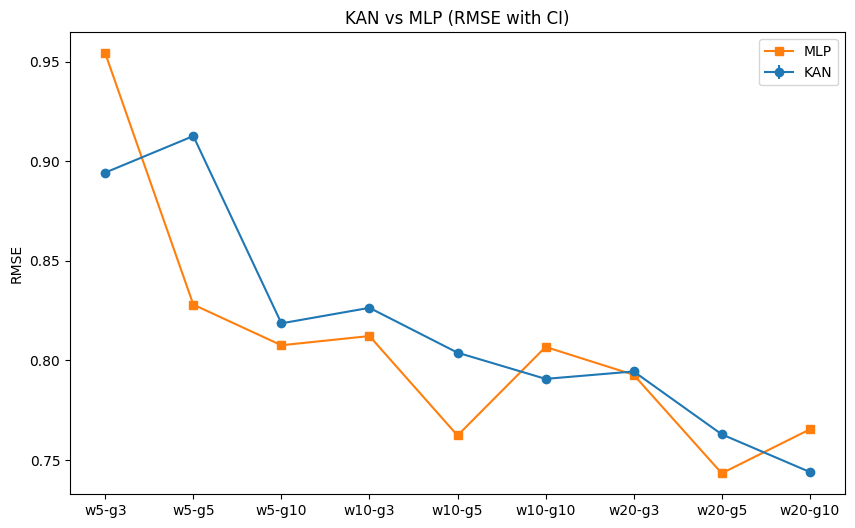

In [ ]:
plt.figure(figsize=(10,6))

plt.errorbar(
    range(len(df)),
    df["KAN_RMSE"],
    yerr=[df["KAN_RMSE"] - df["KAN_RMSE_low"],
          df["KAN_RMSE_high"] - df["KAN_RMSE"]],
    label="KAN",
    marker='o'
)

plt.plot(df["MLP_RMSE"], marker='s', label="MLP")

plt.xticks(range(len(df)), [f"w{w}-g{g}" for w,g in zip(df.width, df.grid)])
plt.ylabel("RMSE")
plt.title("KAN vs MLP (RMSE with CI)")
plt.legend()
plt.show()

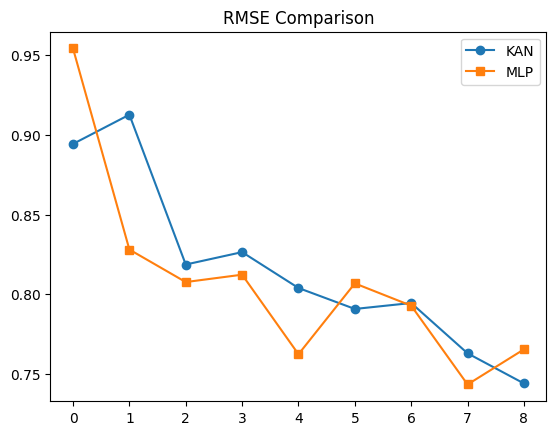

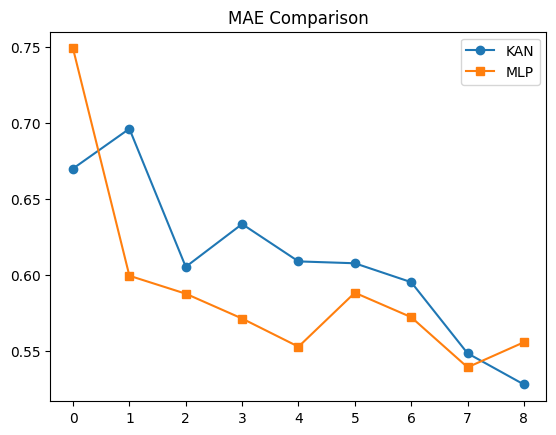

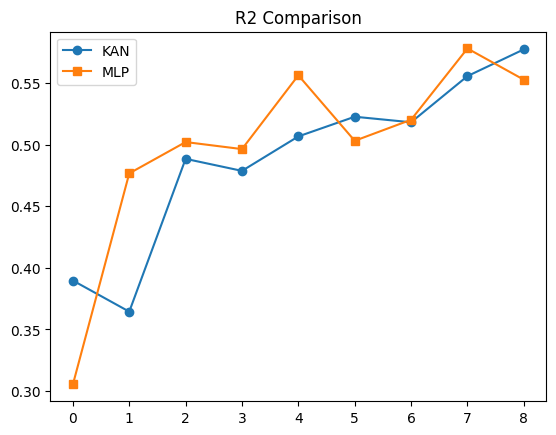

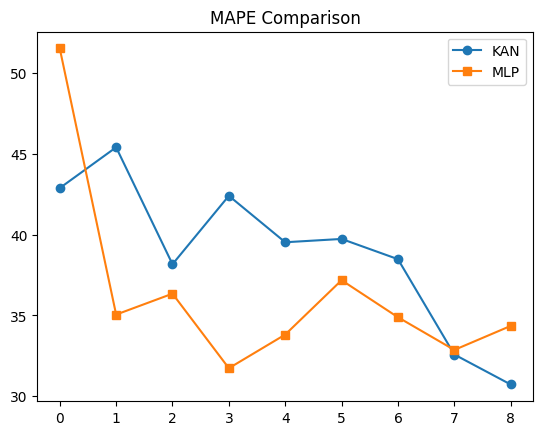

In [ ]:
metrics = ["RMSE", "MAE", "R2", "MAPE"]

for metric in metrics:
    plt.figure()

    plt.plot(df[f"KAN_{metric}"], marker='o', label="KAN")
    plt.plot(df[f"MLP_{metric}"], marker='s', label="MLP")

    plt.title(f"{metric} Comparison")
    plt.legend()
    plt.show()

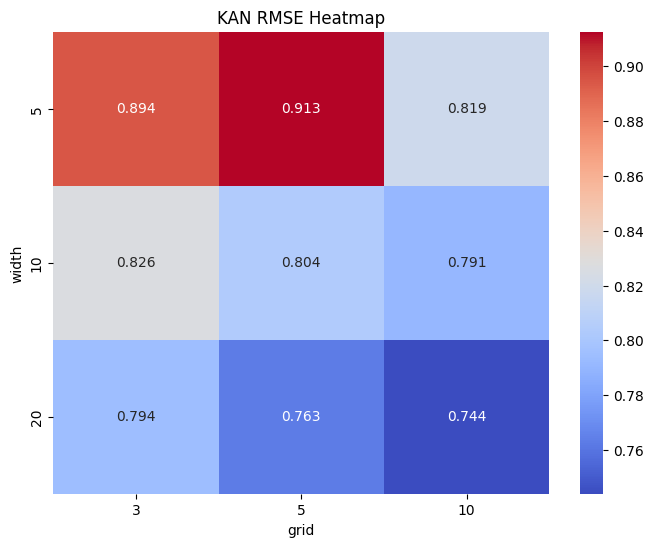

In [ ]:
pivot = df.pivot(index="width", columns="grid", values="KAN_RMSE")

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="coolwarm")
plt.title("KAN RMSE Heatmap")
plt.show()

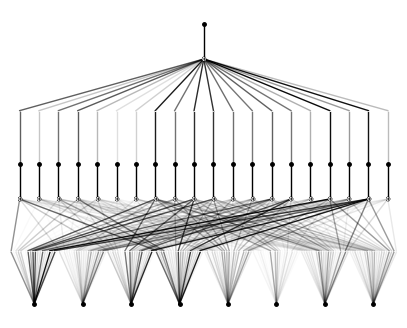

In [ ]:
model_kan.plot(beta=10)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def plot_all_splines(model, layer_idx=0, num_points=200):
    if not hasattr(model, "act_fun"):
        raise AttributeError("The model does not have 'act_fun'.")

    def get_int(val):
        if isinstance(val, list):
            return int(val[0])
        return int(val)

    in_dim = get_int(model.width[layer_idx])
    out_dim = get_int(model.width[layer_idx + 1])

    x = torch.linspace(-3, 3, num_points).unsqueeze(1)
    fig, axes = plt.subplots(out_dim, in_dim, figsize=(3*in_dim, 2*out_dim), squeeze=False)

    for i in range(out_dim):
        for j in range(in_dim):
            X_input = torch.zeros(num_points, in_dim)
            X_input[:, j] = x.squeeze()

            with torch.no_grad():
                # Handle cases where the layer returns a tuple (activations, pre-multiplications)
                output = model.act_fun[layer_idx](X_input)
                if isinstance(output, tuple):
                    output = output[0]
                y = output[:, i].cpu().numpy()

            ax = axes[i, j]
            ax.plot(x.numpy(), y)
            ax.set_title(f"In {j} -> Out {i}", fontsize=8)
            ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

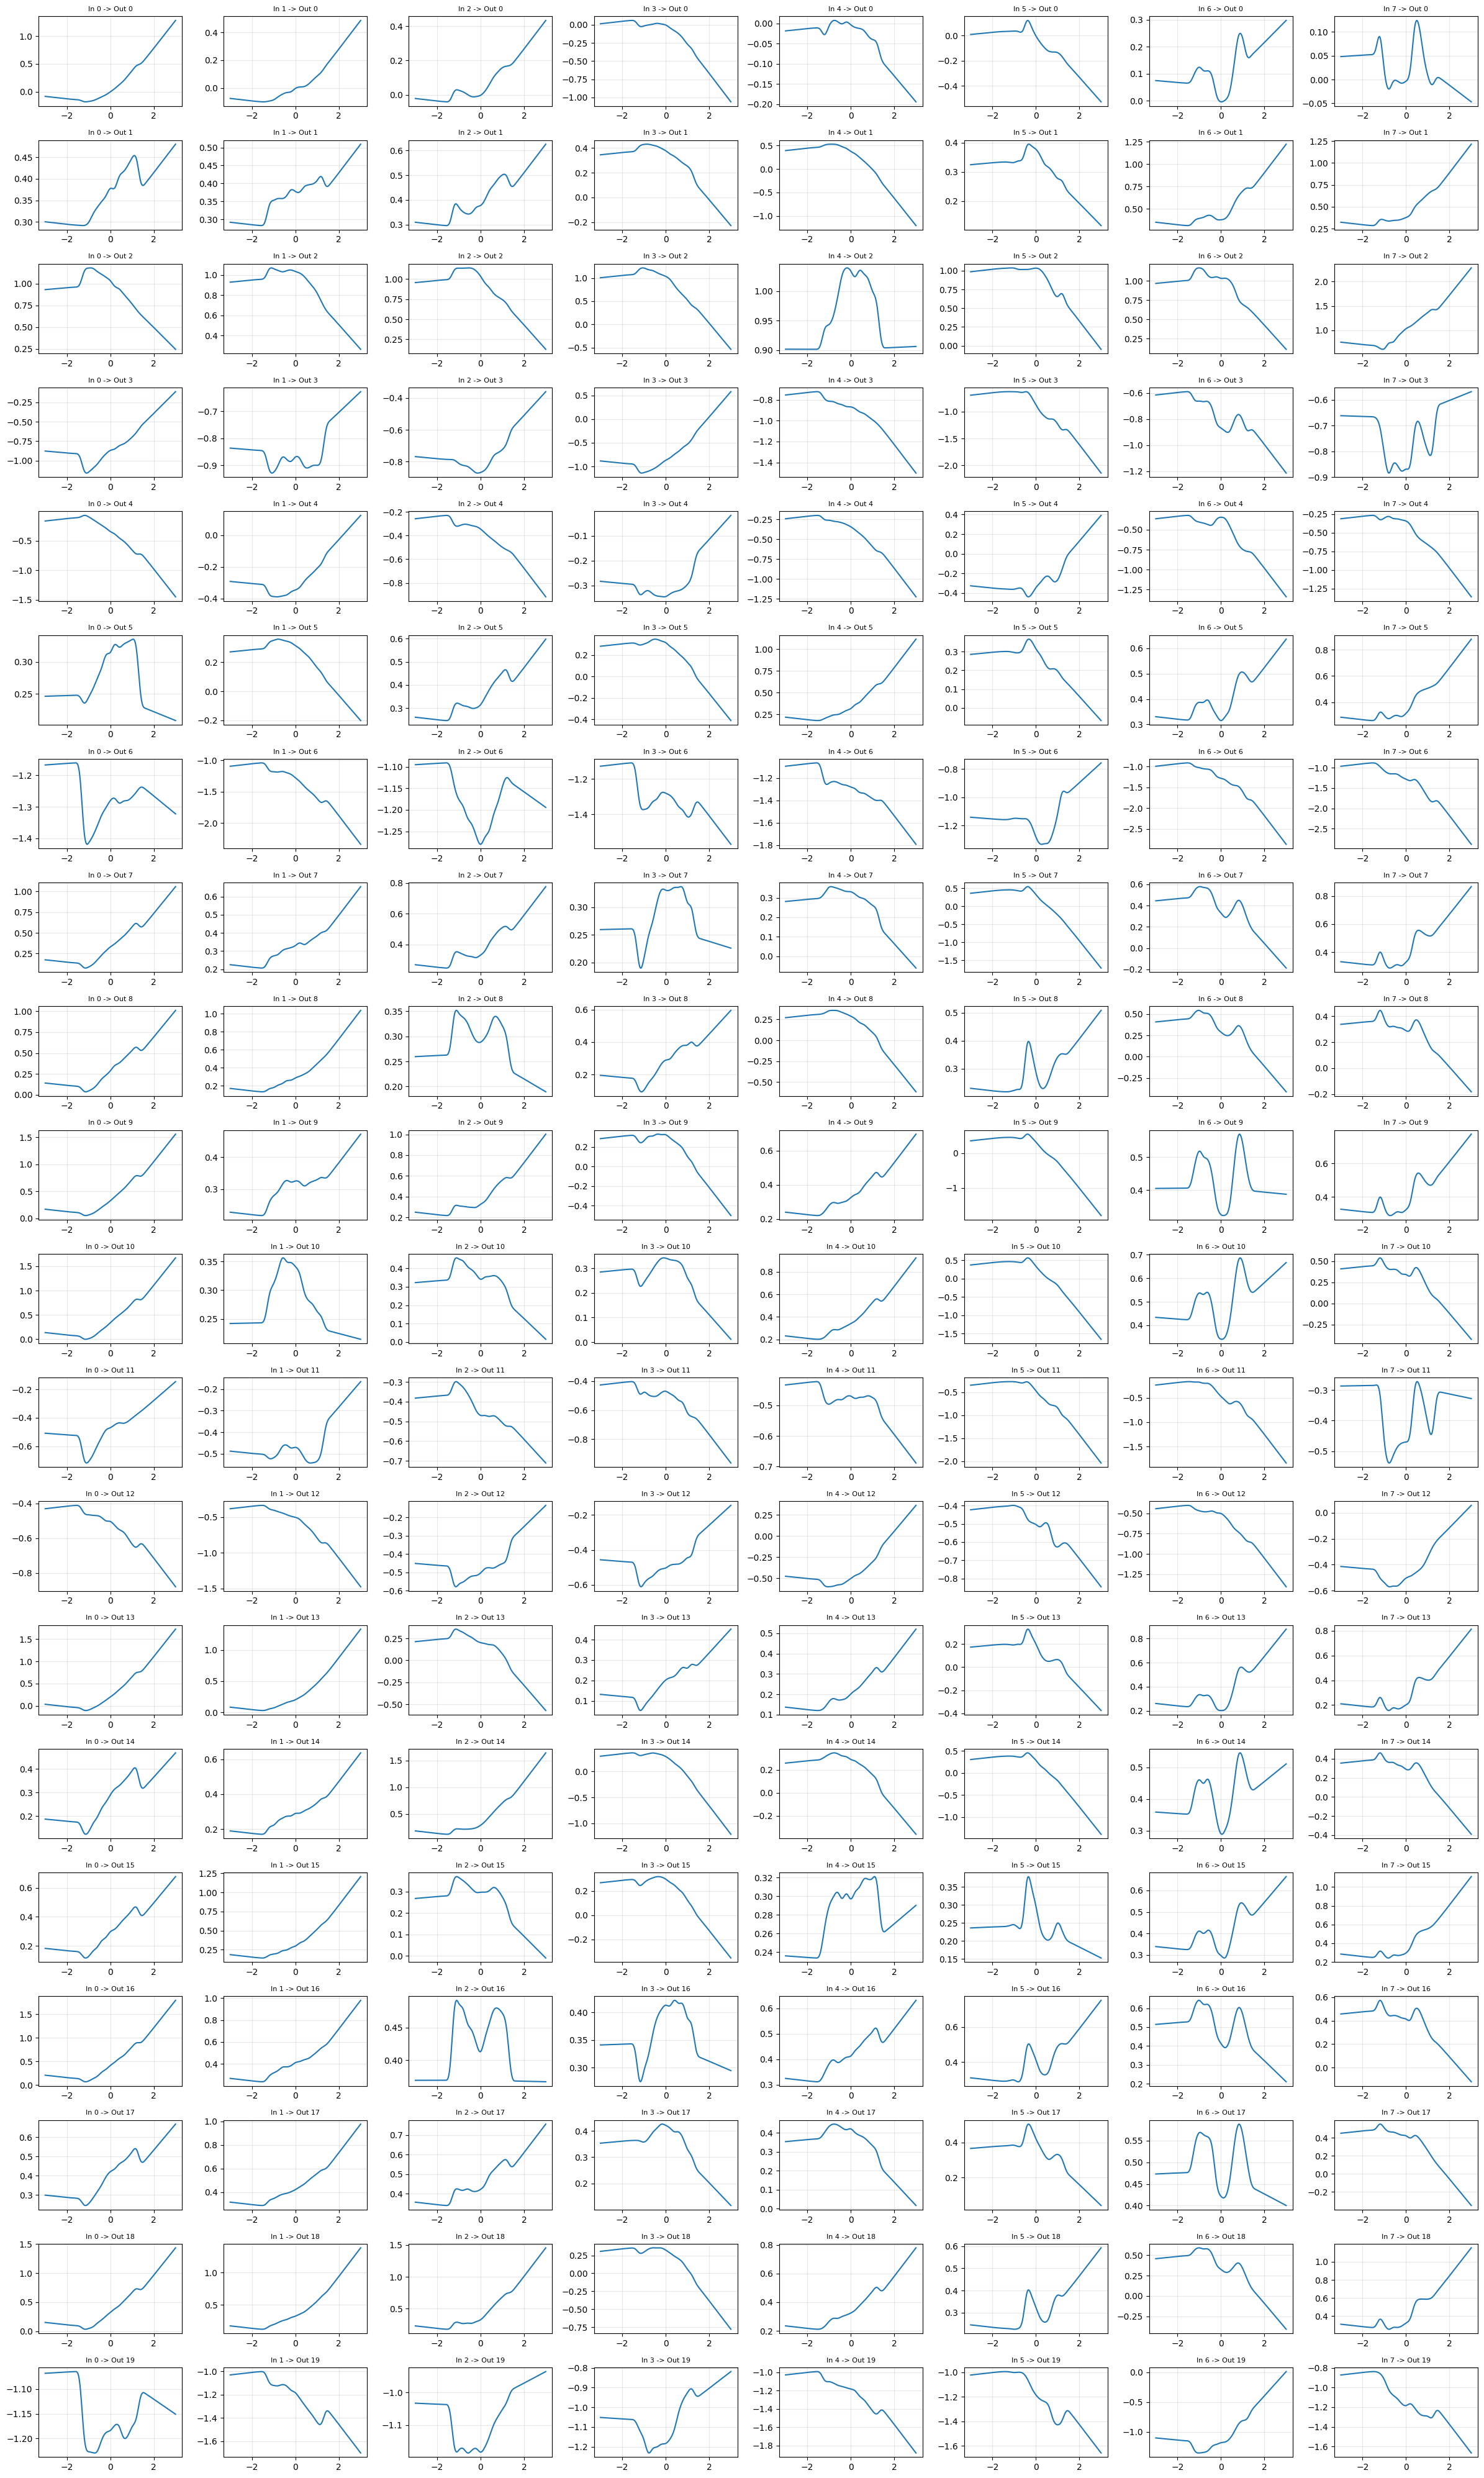

In [ ]:
try:
    # Plotting the first layer splines
    plot_all_splines(model_kan, layer_idx=0)
except Exception as e:
    import traceback
    print(f"Failed to plot: {e}")
    traceback.print_exc()